
# Loan Prediction - Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import joblib
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
from contextlib import contextmanager

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

d:\my_git\loan_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Data
df_loan = pd.read_csv('./datasets/train_ctrUa4K.csv')

print(f'Shape: {df_loan.shape}')
display(df_loan.head())

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Dataset Overview

In [3]:
# Basic statistics of numerical columns
df_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [4]:
obj_cols = [ x for x in df_loan.select_dtypes(include=["object", "string"]).columns if x != "Loan_ID"]
for col in obj_cols:
    unique_values = df_loan[col].unique()

    print(f"{col} (unique values): {unique_values}")
    print("-" * 80)

Gender (unique values): <ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str
--------------------------------------------------------------------------------
Married (unique values): <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
--------------------------------------------------------------------------------
Dependents (unique values): <ArrowStringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str
--------------------------------------------------------------------------------
Education (unique values): <ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
--------------------------------------------------------------------------------
Self_Employed (unique values): <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
--------------------------------------------------------------------------------
Property_Area (unique values): <ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str
---------------------------------

## 2. Missing Value Analysis

,Missing Count,Missing %
Credit_History,50,8.140000
Self_Employed,32,5.210000
LoanAmount,22,3.580000
Dependents,15,2.440000
Loan_Amount_Term,14,2.280000
Gender,13,2.120000
Married,3,0.490000


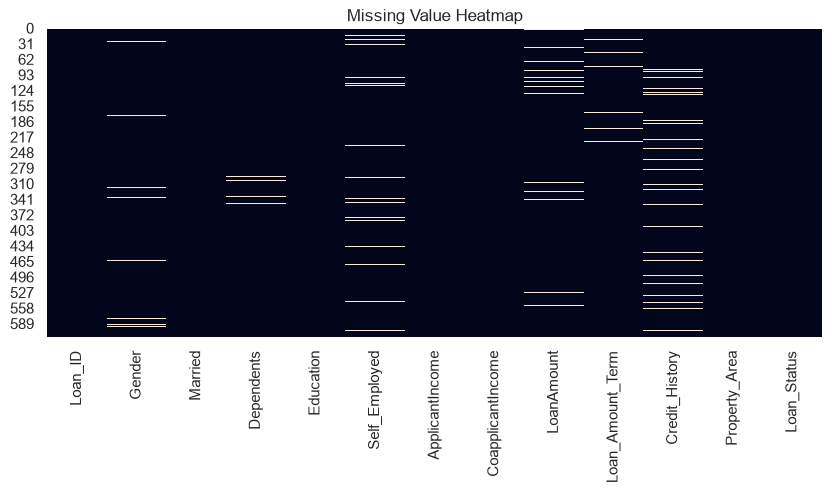

In [5]:
missing = pd.DataFrame({
    'Missing Count': df_loan.isnull().sum(),
    'Missing %': round(df_loan.isnull().mean()*100,2)
})

missing = missing[missing['Missing Count']>0].sort_values('Missing Count',ascending=False)

display(
    missing.style.background_gradient(cmap='Reds')
)

plt.figure(figsize=(10,4))
sns.heatmap(df_loan.isnull(), cbar=False)
plt.title('Missing Value Heatmap')
plt.show()

In [6]:
# ========================================
# Converting Non Missing string columns into numeric
# ========================================

# Loan Status
ls_encoder = LabelEncoder()
df_loan['Loan_Status'] = ls_encoder.fit_transform(df_loan['Loan_Status'])
print("Loan Status: ", dict(zip(ls_encoder.classes_, ls_encoder.transform(ls_encoder.classes_)))) 

# Education
ed_encoder = LabelEncoder()
df_loan['Education'] = ed_encoder.fit_transform(df_loan['Education'])
print("Education: ", dict(zip(ed_encoder.classes_, ed_encoder.transform(ed_encoder.classes_)))) 

Loan Status:  {'N': np.int64(0), 'Y': np.int64(1)}
Education:  {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}


In [7]:
df_area = pd.get_dummies(df_loan['Property_Area'],drop_first=True, dtype=int )
df_loan = pd.concat([df_loan, df_area], axis=1)
df_loan.head() 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Semiurban,Urban
0,LP001002,Male,No,0,0,No,5849,0.0,NaN,360.0,1.0,Urban,1,0,1
1,LP001003,Male,Yes,1,0,No,4583,1508.0,128.0,360.0,1.0,Rural,0,0,0
2,LP001005,Male,Yes,0,0,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,0,1
3,LP001006,Male,Yes,0,1,No,2583,2358.0,120.0,360.0,1.0,Urban,1,0,1
4,LP001008,Male,No,0,0,No,6000,0.0,141.0,360.0,1.0,Urban,1,0,1


In [8]:
# ========================================
# Imputing Missing Gender
# ========================================
df_temp = df_loan.groupby(by='Gender', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Gender,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,Female,112,0.669643,4643.473214,1108.008929,126.697248,352.293578,0.831683
1,Male,489,0.693252,5446.460123,1742.932352,149.265957,339.665272,0.847007
2,NaN,13,0.615385,10333.538462,1465.692308,208.538462,341.538462,0.750000


In [9]:
df_loan['Gender'] = np.where(
    df_loan['Gender'].isna(), np.where(df_loan['ApplicantIncome'] < 5000, 'Female', 'Male'), df_loan['Gender']
)
le = LabelEncoder()
df_loan['Gender'] = le.fit_transform(df_loan['Gender'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 

{'Female': np.int64(0), 'Male': np.int64(1)}


In [10]:
# ========================================
# Imputing Missing Married status
# ========================================
df_temp = df_loan.groupby(by='Married', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Married,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,No,213,0.629108,4970.384977,1316.558685,128.883495,351.115385,0.839196
1,Yes,398,0.716080,5629.173367,1794.632965,155.750000,336.987147,0.842541
2,NaN,3,1.000000,6207.000000,251.333333,159.000000,360.000000,1.000000


In [11]:
df_loan['Married'] = df_loan['Married'].fillna("Yes")
le = LabelEncoder()
df_loan['Married'] = le.fit_transform(df_loan['Married'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 

{'No': np.int64(0), 'Yes': np.int64(1)}


In [12]:
# ========================================
# Imputing Missing Dependents
# ========================================
df_temp = df_loan.groupby(by='Dependents', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Dependents,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,0,345,0.689855,4917.423188,1623.696000,135.886228,348.107784,0.857595
1,1,102,0.647059,5962.274510,1426.235294,158.622449,329.346535,0.844444
2,2,101,0.752475,4926.782178,1687.245544,150.224490,340.871287,0.852632
3,3+,51,0.647059,8581.215686,2024.313725,190.897959,325.200000,0.770833
4,NaN,15,0.600000,5187.600000,1076.133333,128.384615,355.714286,0.666667


In [13]:
# Imputing the missing dependant as 0 as the co-applicant income is very low and so is the loan amount
df_loan['Dependents'] = np.where(
    df_loan['Dependents'] == "3+", '3',np.where(df_loan['Dependents'].isnull(), '0', df_loan["Dependents"])
).astype('float').astype('int')
df_temp = df_loan.groupby(by="Dependents", as_index=False, dropna=False)['Loan_Status'].mean()
df_temp.head()

,Dependents,Loan_Status
0,0,0.686111
1,1,0.647059
2,2,0.752475
3,3,0.647059


In [14]:
# ========================================
# Imputing Missing Self_Employed
# ========================================
df_temp = df_loan.groupby(by='Self_Employed', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Self_Employed,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,No,500,0.686000,5049.748000,1580.989840,141.748963,343.263804,0.835853
1,Yes,82,0.682927,7380.817073,1501.341463,172.000000,336.300000,0.840000
2,NaN,32,0.718750,5863.218750,2557.500000,153.709677,336.774194,0.961538


In [15]:
df_loan['Self_Employed'] = df_loan['Self_Employed'].fillna("No")
le = LabelEncoder()
df_loan['Self_Employed'] = le.fit_transform(df_loan['Self_Employed'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 

{'No': np.int64(0), 'Yes': np.int64(1)}


In [16]:
# ========================================
# Imputing Missing Credit History
# ========================================
df_temp = df_loan.groupby(by='Credit_History', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Credit_History,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,0.0,89,0.078652,5679.438202,1542.179775,146.717647,341.927711
1,1.0,475,0.795789,5426.526316,1528.250358,144.786026,342.192719
2,NaN,50,0.740000,4693.080000,2645.440000,161.081633,340.320000


In [17]:
df_loan['Credit_History'] = df_loan["Credit_History"].fillna(1)
df_temp = df_loan.groupby(by='Credit_History', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean'})
df_temp.head()

,Credit_History,Loan_ID,Loan_Status
0,0.0,89,0.078652
1,1.0,525,0.790476


In [18]:
# ========================================
# Imputing Missing Loan_Amount_Term
# ========================================
lat_med = df_loan['Loan_Amount_Term'].median()
df_loan['Loan_Amount_Term'] = df_loan['Loan_Amount_Term'].fillna(lat_med)

In [19]:
# ========================================
# Imputing Missing Loan_Amount
# ========================================
lat_med = df_loan['LoanAmount'].mean()
df_loan['LoanAmount'] = df_loan['LoanAmount'].fillna(lat_med)

In [20]:
df_loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Semiurban            0
Urban                0
dtype: int64

In [21]:
df_loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Semiurban,Urban
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,Urban,1,0,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,Rural,0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,Urban,1,0,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,Urban,1,0,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,Urban,1,0,1


In [22]:
df_loan.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Semiurban,Urban
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.804560,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,146.412162,342.410423,0.855049,0.687296,0.379479,0.328990
std,0.396862,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.037468,64.428629,0.352339,0.463973,0.485653,0.470229
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,129.000000,360.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000,1.000000,1.000000


## 3. Outlier Analysis

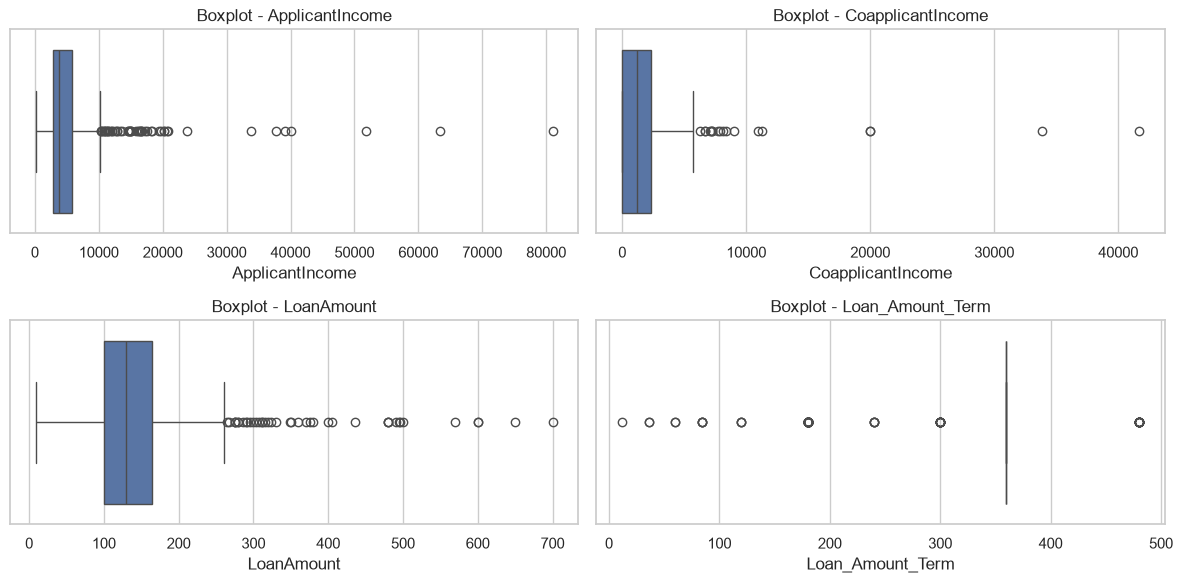

In [23]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 
            'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for col, ax in zip(num_cols, axes.flatten()):
    sns.boxplot(x=df_loan[col], ax=ax)
    ax.set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

* We will have to use some prediction methods that are not affected by outliers

In [24]:
df_loan1 = df_loan.drop(['Loan_ID', 'Property_Area'], axis=1)

df_loan1.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Semiurban,Urban
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,1,0,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,1,0,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,1,0,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,1,0,1


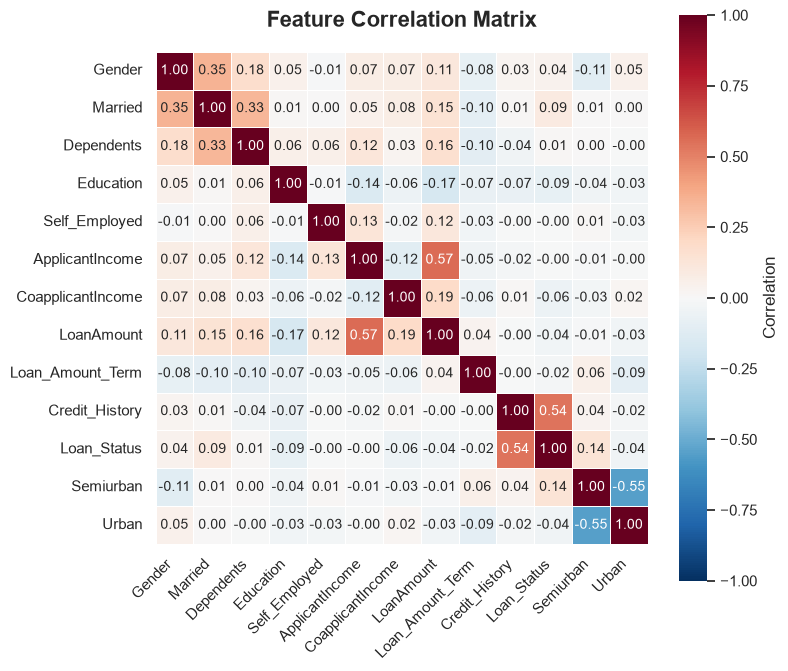

In [25]:
df_cor = df_loan1.corr('pearson')

plt.figure(figsize=(8,8))

sns.heatmap(
    df_cor,
    annot=True,             # Show correlation values
    fmt=".2f",
    cmap="RdBu_r",          # Blue = negative, Red = positive
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    },
    annot_kws={"size": 10}
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
# @contextmanager
# def tqdm_joblib(tqdm_object):
#     class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
#         def __call__(self, *args, **kwargs):
#             tqdm_object.update(n=self.batch_size)
#             return super().__call__(*args, **kwargs)

#     old_callback = joblib.parallel.BatchCompletionCallBack
#     joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

#     try:
#         yield tqdm_object
#     finally:
#         joblib.parallel.BatchCompletionCallBack = old_callback
#         tqdm_object.close()

In [27]:
X = df_loan1[[x for x in df_loan1.columns if x !="Loan_Status"]]
y = df_loan1['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
print(f"X_train: {X_train.shape}, y_test: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (460, 12), y_test: (460,), X_test: (154, 12), y_test: (154,)


In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [29]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 15],
    'subsample': [0.7, 0.85, 1.0]
}
total_fits = cv.get_n_splits()
for param in gb_params.keys():
    total_fits *= len(gb_params[param])

gbc = GradientBoostingClassifier(random_state=42)
clf_gb = GridSearchCV(gbc, gb_params, scoring='roc_auc', cv=cv, n_jobs=-1)

with tqdm_joblib(
    tqdm(
        total=total_fits,
        unit="fit"
    )
):
    clf_gb.fit(X_train, y_train)

print("Best parameters:", clf_gb.best_params_)
print("Best CV score:", clf_gb.best_score_)

100%|██████████| 3645/3645 [04:10<00:00, 14.54it/s]

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 15, 'min_samples_split': 50, 'n_estimators': 100, 'subsample': 0.85}
Best CV score: 0.748644943019943


In [30]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

total_fits = cv.get_n_splits()
for param in rf_params.keys():
    total_fits *= len(rf_params[param])

rf = RandomForestClassifier(random_state=42)
clf_rf = GridSearchCV(rf, rf_params, scoring='roc_auc', cv=5, n_jobs=-1)

with tqdm_joblib(
    tqdm(
        total=total_fits,
        unit="fit"
    )
):
    clf_rf.fit(X_train, y_train)

print("Best parameters:", clf_rf.best_params_)
print("Best CV score:", clf_rf.best_score_)










































































































































































































































































































































































































































































































































































































































































































































100%|██████████| 1620/1620 [02:44<00:00,  9.84it/s]

Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV score: 0.7887920355107856


In [40]:
clf_rf.feature_names_in_

array(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Semiurban', 'Urban'],
      dtype=object)

  0%|          | 0/1620 [02:44<?, ?fit/s]


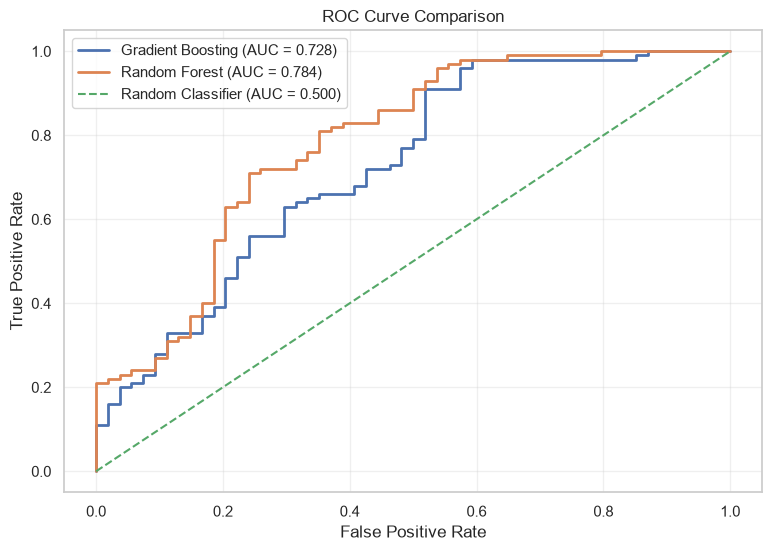

In [31]:
models = {
    "Gradient Boosting": clf_gb,
    "Random Forest": clf_rf
}

results = {}

plt.figure(figsize=(9, 6))

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
results_df = pd.DataFrame(results).T

display(
    results_df.style
    .format("{:.3f}")
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.766,0.750,0.960,0.842,0.728
Random Forest,0.779,0.754,0.980,0.852,0.784


In [36]:
import pickle
with open("./models/model.pkl", "wb") as file:
    pickle.dump(clf_rf, file)